In [3]:
# Install kaggle if not already installed
!pip install kaggle --user

     ---------------------------------------- 0.0/181.2 kB ? eta -:--:--
     -- ------------------------------------- 10.2/181.2 kB ? eta -:--:--
     -- ------------------------------------- 10.2/181.2 kB ? eta -:--:--
     -------------- ---------------------- 71.7/181.2 kB 491.5 kB/s eta 0:00:01
     ---------------------------- ------- 143.4/181.2 kB 711.9 kB/s eta 0:00:01
     ---------------------------------- - 174.1/181.2 kB 807.1 kB/s eta 0:00:01
     ------------------------------------ 181.2/181.2 kB 730.8 kB/s eta 0:00:00
     ---------------------------------------- 0.0/78.4 kB ? eta -:--:--
     --------------- ------------------------ 30.7/78.4 kB ? eta -:--:--
     ----------------------------- -------- 61.4/78.4 kB 656.4 kB/s eta 0:00:01
     -------------------------------------- 78.4/78.4 kB 625.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/78.2 kB ? eta -:--:--
     --------------- ------------------------ 30.7/78.2 kB ? eta -:--:--
     ----


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os

# Create folder for dataset
os.makedirs("dataset", exist_ok=True)

In [12]:
import os

# Point Kaggle to the folder containing kaggle.json
os.environ['KAGGLE_CONFIG_DIR'] = r"C:\Users\Keerthi\OneDrive\potato-disease-classification\kaggle"

In [14]:
!kaggle datasets list

ref                                                         title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                    BMW Global Automotive Sales                           55017  2026-02-22 18:18:38                  3672         72  1.0              
suhanigupta04/student-placement-prediction-dataset          Student Placement Prediction Dataset                1873115  2026-03-02 07:41:44.213000            980         31  1.0              
aliiihussain/amazon-sales-dataset                           Amazon_Sales_Dataset                                1297759  2026-02-01 11:37:12.353000          11701        176  1.0              
shree0910/online-vs-in-store-shoppi

In [ ]:
import os

# Set path to your kaggle.json folder
os.environ['KAGGLE_CONFIG_DIR'] = r"C:\Users\Keerthi\OneDrive\potato-disease-classification\kaggle"

# Download the PlantVillage Potato Disease dataset
!kaggle datasets download -d emmarex/plantdisease -p dataset --unzip

In [ ]:
import os

# List files to make sure dataset downloaded correctly
os.listdir("dataset")

In [ ]:
# Step 1: Set image parameters
IMAGE_SIZE = 128   # You can also use 224
BATCH_SIZE = 32

# Step 2: Import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 3: Create training and validation generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    validation_split=0.2   # 20% for validation
)

train_generator = train_datagen.flow_from_directory(
    'dataset',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    'dataset',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation'
)

In [ ]:
# Step 4: Import TensorFlow and Keras modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Step 5: Build the CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')  # Number of output classes
])

# Step 6: Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 7: View model summary
model.summary()

In [ ]:
# Step 8: Import callbacks to save the best model
from tensorflow.keras.callbacks import ModelCheckpoint

# Step 9: Set up model checkpoint to save best weights
checkpoint = ModelCheckpoint(
    "potato_disease_model.h5",   # File where the best model will be saved
    monitor="accuracy",          # You can also monitor 'val_accuracy' if using validation
    save_best_only=True,
    verbose=1
)

# Step 10: Train the model
history = model.fit(
    train_generator,
    epochs=15,                   # You can increase later
    callbacks=[checkpoint]
)

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load the trained model
model = load_model("potato_disease_model.h5")

# Define your class labels (check train_generator.class_indices for exact mapping)
class_labels = list(train_generator.class_indices.keys())
print("Class labels:", class_labels)

In [ ]:
# Path to the test image
img_path = "dataset/test/sample_leaf.jpg"  # Replace with your image

# Load the image with the same target size as training
img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))

# Convert to array and scale
img_array = image.img_to_array(img) / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
prediction = model.predict(img_array)
predicted_class = class_labels[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [3]:
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')

])

In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

In [11]:
import os

train_path = r"C:\Users\Keerthi\OneDrive\potato-disease-classification\training\dataset\train"

for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)
    if os.path.isdir(folder_path):
        print(folder, "has", len(os.listdir(folder_path)), "images")

Early_blight has 3 images
Healthy has 5 images
Late_blight has 5 images


In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=2,
    class_mode='categorical'
)

Found 13 images belonging to 3 classes.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 62, 62, 16)        448       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 31, 31, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 29, 29, 32)        4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 6272)              0         
                                                                 
 dense_2 (Dense)             (None, 32)               

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [14]:
IMAGE_SIZE = 64  # smaller size for your tiny dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    'dataset/train',  # your training folder path
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=2,
    class_mode='categorical'
)

Found 13 images belonging to 3 classes.


In [15]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes: Early_blight, Healthy, Late_blight
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [16]:
!pip install scipy


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 62, 62, 16)        448       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 31, 31, 16)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 29, 29, 32)        4640      
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 flatten_4 (Flatten)         (None, 6272)              0         
                                                                 
 dense_8 (Dense)             (None, 32)               

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # assuming 3 classes of potato disease
])

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
!pip install matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 11 images belonging to 7 classes.
Found 2 images belonging to 7 classes.
Epoch 1/10
1/1 [==============================] - 2s 2s/step - loss: 1.9605 - accuracy: 0.0000e+00 - val_loss: 0.4392 - val_accuracy: 1.0000
Epoch 2/10
1/1 [==============================] - 0s 334ms/step - loss: 0.4694 - accuracy: 1.0000 - val_loss: 0.0049 - val_accuracy: 1.0000
Epoch 3/10
1/1 [==============================] - 0s 378ms/step - loss: 0.0180 - accuracy: 1.0000 - val_loss: 4.7088e-06 - val_accuracy: 1.0000
Epoch 4/10
1/1 [==============================] - 0s 475ms/step - loss: 4.1676e-04 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 5/10
1/1 [==============================] - 0s 279ms/step - loss: 4.8767e-07 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 6/10
1/1 [==============================] - 0s 307ms/step - loss: 4.3349e-08 - accuracy: 1.0000 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 7/10
1/1 [==============================] - 0s

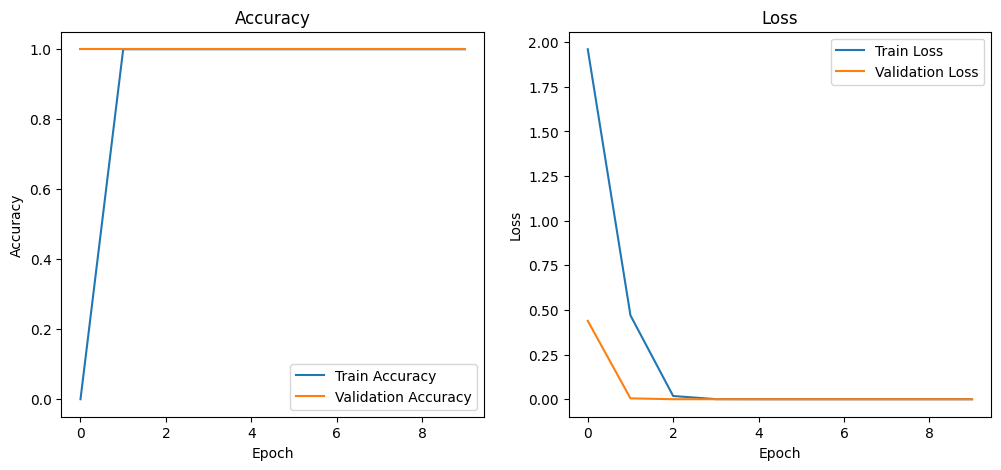

In [12]:
# =========================
# Potato Disease Classification - Fixed Full Code
# =========================

# Step 1: Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Step 2: Data Generators
dataset_path = r"C:\Users\Keerthi\OneDrive\potato-disease-classification"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Step 3: Define CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')  # 7 classes in your dataset
])

# Step 4: Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 5: Train Model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Step 6: Save the model
model.save(r"C:\Users\Keerthi\OneDrive\potato-disease-model.h5")
print("Model saved successfully!")

# Step 7: Plot Accuracy and Loss
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [18]:
# ==============================
# Potato Disease Classification - Transfer Learning
# ==============================

# Step 1: Imports
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np
import os

# Step 2: Correct Dataset Path
# Make sure this folder contains subfolders for each disease class
dataset_path = r"C:\Users\Keerthi\OneDrive\potato-disease-classification\training\dataset\train"

# Step 3: Data Generators with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2  # 20% for validation
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

# Step 4: Save the class names in order
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

# Step 5: Build Transfer Learning Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base layers

inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

# Step 6: Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 7: Train
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Step 8: Save Model
model_save_path = r"C:\Users\Keerthi\OneDrive\potato-disease-model-transfer.h5"
model.save(model_save_path)
print("Model saved at:", model_save_path)

# ==============================
# Step 9: Prediction Function
# ==============================
def predict_image(img_path):
    img = load_img(img_path, target_size=(224,224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    preds = model.predict(img_array)
    predicted_index = np.argmax(preds[0])
    confidence = np.max(preds[0])
    
    predicted_class = class_names[predicted_index]
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence*100:.2f}%")
    
    return predicted_class, confidence

# ==============================
# Step 10: Test Prediction
# ==============================
test_img_path = r"C:\Users\Keerthi\OneDrive\potato-disease-classification\training\dataset\train\Early_blight\early1.jpg"
predict_image(test_img_path)

Found 11 images belonging to 3 classes.
Found 2 images belonging to 3 classes.
Classes: ['Early_blight', 'Healthy', 'Late_blight']
Epoch 1/10
1/1 [==============================] - 7s 7s/step - loss: 1.7227 - accuracy: 0.4545 - val_loss: 1.1092 - val_accuracy: 0.5000
Epoch 2/10
1/1 [==============================] - 1s 746ms/step - loss: 1.0411 - accuracy: 0.3636 - val_loss: 1.1823 - val_accuracy: 0.5000
Epoch 3/10
1/1 [==============================] - 1s 778ms/step - loss: 1.6219 - accuracy: 0.2727 - val_loss: 0.6714 - val_accuracy: 0.5000
Epoch 4/10
1/1 [==============================] - 1s 755ms/step - loss: 0.7719 - accuracy: 0.6364 - val_loss: 1.0540 - val_accuracy: 0.5000
Epoch 5/10
1/1 [==============================] - 1s 719ms/step - loss: 0.8570 - accuracy: 0.7273 - val_loss: 0.8483 - val_accuracy: 0.5000
Epoch 6/10
1/1 [==============================] - 1s 637ms/step - loss: 0.4129 - accuracy: 0.9091 - val_loss: 0.8391 - val_accuracy: 0.5000
Epoch 7/10
1/1 [================

('Early_blight', 0.8153691)

In [19]:
# Save the trained model
model.save(r"C:\Users\Keerthi\OneDrive\potato-disease-model-transfer.h5")
print("Model saved successfully!")

Model saved successfully!
